# N2 Binding Curve (UCCSD Statevector)

This notebook reads `vqe_result.json` files from `results/UCCSD/N2_binding/statevector_results`, extracts:
- bond length from `molecule` (e.g. `N2_1450 -> 1.450 Å`)
- VQE energy from `final_total_energy`

It then overlays the VQE curve with the frozen-core FCI reference curve from `givens_vqe.data.molecules.reference_energies`.

In [32]:
import importlib
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt

import givens_vqe.data.molecules as molecules_mod
from givens_vqe.data import mlc_dict


reference_energies = molecules_mod.reference_energies

RESULTS_ROOT = Path("/Users/eline/personal/QMC_Givens_ansatz_results/")

COLORS = {
    "H1-1": "#F24236",
    "H1-1E": "#0077B6",
    "H1-1_annotation": "#7D2528",
    "H1-1E_annotation": "#001f3f",
    "UCCSD": "#784c00",
    "UCCSD_annotation": "#291211",
    "Statevector": "#48C9B0",
    "HF_baseline": "#444444",
}
colors = ["#F24236", "#0077B6",  "#7D2528", "#001f3f", "#784c00", "#48C9B0"]


def parse_bond_length_from_molecule_key(molecule_key: str) -> float:
    """Parse N2_XXXX molecule keys into bond lengths in Angstrom."""
    if molecule_key == "N2":
        return 1.098

    match = re.fullmatch(r"N2_(\d{4})", molecule_key)
    if not match:
        raise ValueError(f"Unsupported molecule key format: {molecule_key}")

    return int(match.group(1)) / 1000.0


def load_vqe_points(results_path: Path):
# Load VQE points from all vqe_result.json files.
    vqe_points = []
    initial_energies = []
    for json_path in sorted(results_path.glob("*.json")):
        with json_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        molecule_key = data.get("molecule")
        final_total_energy = data.get("final_total_energy")
        initial_energies.append(data.get("initial_energy") + mlc_dict[molecule_key].nuclear_energy if molecule_key in mlc_dict else None)

        if molecule_key is None or final_total_energy is None:
            continue

        bond_length = parse_bond_length_from_molecule_key(molecule_key)
        vqe_points.append((bond_length, float(final_total_energy), molecule_key))

    vqe_points.sort(key=lambda x: x[0])
    return vqe_points, initial_energies


def build_reference_points(vqe_points):
# Build reference points using the same molecule keys as VQE, when available.
    ref_points = []
    missing_reference_keys = []
    for bond_length, _, molecule_key in vqe_points:
        if molecule_key in reference_energies:
            ref_points.append(
                (
                    bond_length,
                    float(reference_energies[molecule_key])
                    + mlc_dict[molecule_key].nuclear_energy,
                    molecule_key,
                )
            )
        else:
            missing_reference_keys.append(molecule_key)

    return ref_points, missing_reference_keys

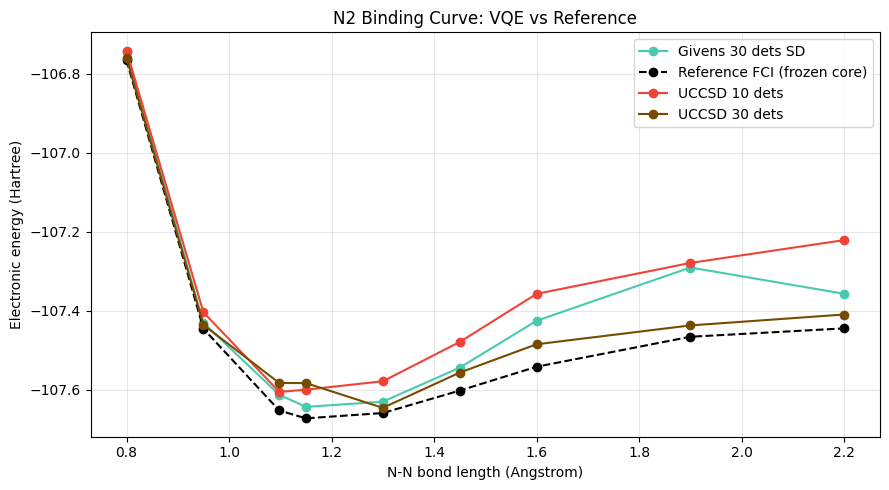

In [43]:
dirs = [ 
    "Givens_results/statevector/N2/binding_curve/30_dets_sd",
    "UCCSD_results/statevector/binding_curve/10_dets",
    "UCCSD_results/statevector/binding_curve/30_dets"
    
]

labels = [
    "Givens 30 dets SD",
    "UCCSD 10 dets",
    "UCCSD 30 dets"
]

colors_plot = [
    colors[5],
    colors[0],
    colors[4]
]

plt.figure(figsize=(9, 5))
ref_plotted = False
initial_plotted = True

for i, dir in enumerate(dirs):
    vqe_points, initial_energy = load_vqe_points(RESULTS_ROOT / dir)
    label = labels[i]
    vqe_x = [p[0] for p in vqe_points]
    vqe_y = [p[1] for p in vqe_points]

    plt.plot(vqe_x, vqe_y, marker="o", linewidth=1.5, label=label, color=colors_plot[i])

    if not ref_plotted:
        ref_points, missing_keys = build_reference_points(vqe_points)
        if ref_points:
            ref_x = [p[0] for p in ref_points]
            ref_y = [p[1] for p in ref_points]
            plt.plot(ref_x, ref_y, marker="o", linewidth=1.5, linestyle="--", color="black", label="Reference FCI (frozen core)")
            ref_plotted = True
        if missing_keys:
            print("Missing reference keys:", sorted(set(missing_keys)))

    if not initial_plotted:
        plt.plot(vqe_x, initial_energy, color="grey", linestyle=":", label="Initial Energy", marker="x")
        initial_plotted = True

plt.xlabel("N-N bond length (Angstrom)")
plt.ylabel("Electronic energy (Hartree)")
plt.title("N2 Binding Curve: VQE vs Reference")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()